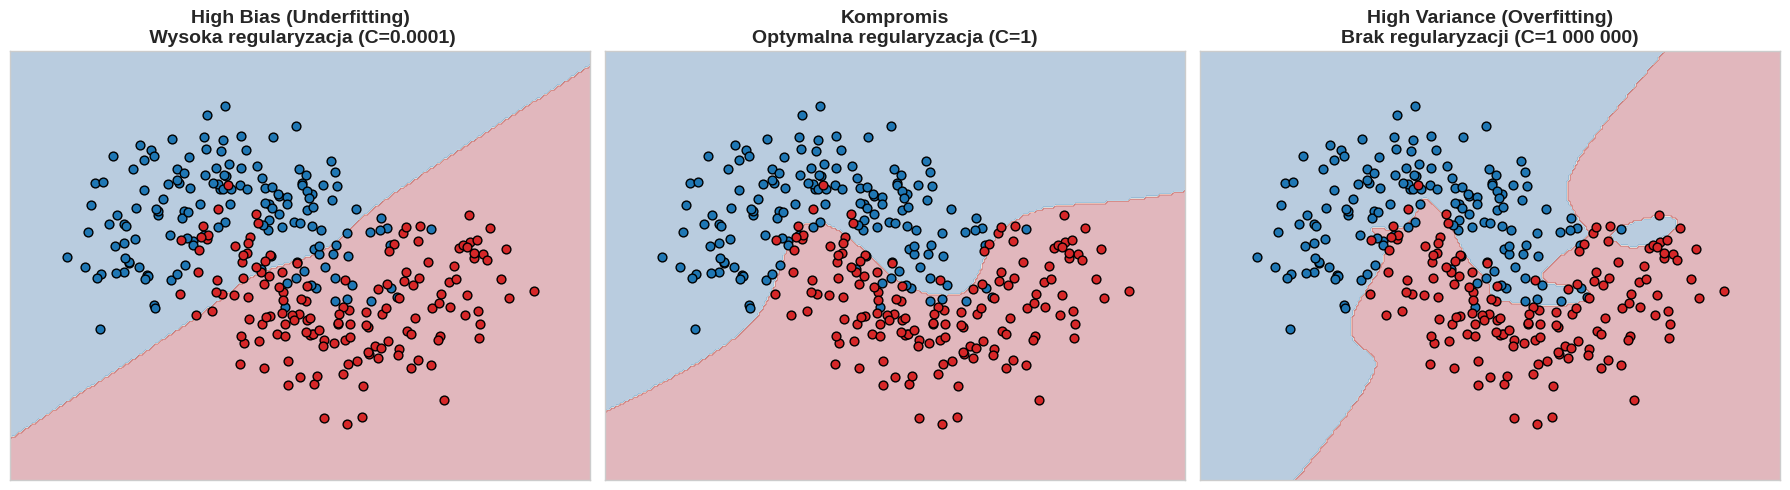

In [3]:
# Pomocniczy notatnik do wizualizacji Obciążenia i Wariancji
# ten materiał (kod) nie jest obowiązkowy w projekcie grupowym

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import validation_curve, GridSearchCV


# Ustawienia estetyczne wykresów
plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#1f77b4', '#d62728'] # Niebieski i czerwony

# Generowanie danych ("Sygnał" i "Szum")
# Tworzymy dwa półksiężyce (make_moons) i dodajemy spory szum (parametr noise)
X, y = make_moons(n_samples=300, noise=0.28, random_state=22)

# wykres punktowy do wizualizacji zbioru dancyh
def plot_data(X, y, ax):
    ax.scatter(X[y==0, 0], X[y==0, 1], c=colors[0], edgecolors='k', s=40, label='Klasa 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], c=colors[1], edgecolors='k', s=40, label='Klasa 1')
    ax.set_xticks(())
    ax.set_yticks(())

# uproszczona funkcja pomocnicza do rysowania granic decyzyjnych
def plot_decision_boundary(model, X, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu_r')
    plot_data(X, y, ax)
    ax.set_title(title, fontsize=14, fontweight='bold')

# Tworzymy model
# Używamy Pipeline: Standaryzacja -> Transformacja wielomianowa 7 stopnia -> Regresja Logistyczna
# Transformacja wielomianowa daje regresji logistycznej potencjał do duzego overfittingu

def get_pipeline(C_value):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=7)), # duża elastyczność
        ('logreg', LogisticRegression(penalty='l2', C=C_value, solver='liblinear', max_iter=10000))
    ])

# Wizualizacjia rezultatu: Underfitting vs Kompromis vs Overfitting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Model 1: Skrajny underfitting (Bardzo silna regularyzacja, C bliskie zeru)
model_underfit = get_pipeline(C_value=0.0001).fit(X, y)
plot_decision_boundary(model_underfit, X, axes[0], "High Bias (Underfitting)\n Wysoka regularyzacja (C=0.0001)")

# Model 2: Złoty środek (Umiarkowana regularyzacja)
model_good = get_pipeline(C_value=1).fit(X, y)
plot_decision_boundary(model_good, X, axes[1], "Kompromis\nOptymalna regularyzacja (C=1)")

# Model 3: Skrajny Overfitting (Brak regularyzacji, C ogromne)
model_overfit = get_pipeline(C_value=1000000).fit(X, y)
plot_decision_boundary(model_overfit, X, axes[2], "High Variance (Overfitting)\nBrak regularyzacji (C=1 000 000)")

plt.tight_layout()
plt.show()


Zobaczcie na wykres po prawej. Model oszalał i zaczyna uczyć się przykładów na pamięć.
Rysuje wysepki wokół pojedynczych niebieskich kropek. To jest czysty szum.

Wygląda na to, że środkowy obrazek jest najlepszy.
Ale jak to stwierdzić "programistycznie", bez patrzenia na obrazki?

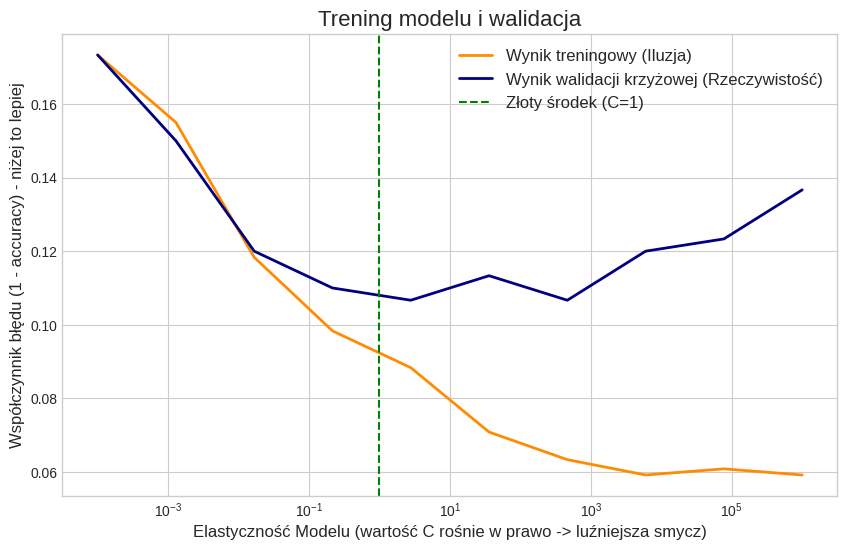

In [4]:

# Walidacja krzyżowa i ewaluacja modelu przy pomocy zbioru testowego
base_model = get_pipeline(C_value=1.0) # inicjalizacja modelu bazowego

# Testujemy szeroki zakres wartości C (od 0.0001 do 1 000 000) na skali logarytmicznej
# i bierzemy 10 równo oddalonych wartości:
param_range = np.logspace(-4, 6, 10)

# Uruchamiamy 5-fold Cross-Validation dla każdej z 10 wartości parametru C
train_scores, test_scores = validation_curve(
    base_model, X, y,
    param_name="logreg__C", # wyjaśnienie: 'logreg' - tak nazwalismy LogisticRegression w pipelinie, C to parametr tegoż modelu
    param_range=param_range,
    cv=5, # 5-krotna walidacja krzyżowa
    scoring="accuracy",
    n_jobs=-1
)

# Uśredniamy wyniki walidacji (metryka accuracy)
train_scores = np.mean(train_scores, axis=1)
test_scores = np.mean(test_scores, axis=1)

# do naszego wykresu wezmiemy tzw. "error rate" (błąd modelu), tj: 1 - accuracy.
train_scores_error_rate = 1 - train_scores
test_scores_error_rate = 1 - test_scores

# Chcemy żeby wartość błędu była najmnijesza.
plt.figure(figsize=(10, 6))
plt.title("Trening modelu i walidacja", fontsize=16)
plt.xlabel("Elastyczność Modelu (wartość C rośnie w prawo -> luźniejsza smycz)", fontsize=12)
plt.ylabel("Współczynnik błędu (1 - accuracy) - niżej to lepiej", fontsize=12)

# Oś X logarytmiczna dla czytelności
plt.semilogx(param_range, train_scores_error_rate, label="Wynik treningowy (Iluzja)", color="darkorange", lw=2)
plt.semilogx(param_range, test_scores_error_rate, label="Wynik walidacji krzyżowej (Rzeczywistość)", color="navy", lw=2)

plt.axvline(x=1, color='green', linestyle='--', label='Złoty środek (C=1)')

plt.legend(loc="upper right", fontsize=12)
plt.show()



Zwróćcie uwagę: pomarańczowa linia (błąd treningowy) cały czas maleje – model jest coraz bardziej z siebie zadowolony.
Ale granatowa linia z walidacji krzyżowej (prawdziwy test) w pewnym momencie przestaje spadać i zaczyna rosnąć.
Dzięki walidacji nasz radar zadziałał i jesteśmy w stanie wybrać optymalny model.